# Exploratory Data Analysis (EDA)
### E-Commerce 360 Analytics

---

### Purpose of this Notebook
In this notebook, we explore 100,000 real Brazilian e-commerce orders across 9 tables.  
Our goal is to understand customer behavior, sales trends, delivery delays, and review ratings so we know **what features to build** in our next step (`05_feature_engineering.ipynb`).

### Python EDA vs. Power BI Dashboard (Zero Duplication)
- **Python EDA (This Notebook):** We find patterns, check distributions, and test business questions (for example: *Does late delivery hurt review scores?*). This is exploratory data work.
- **Power BI (Later):** We build the final interactive dashboard with date filters, KPI cards, and maps for business managers. We do not repeat one-off exploratory code there.

---

In [4]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Simple clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["figure.titlesize"] = 13
plt.rcParams["axes.titlesize"] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# Step 2: Load the 9 Cleaned Base Tables (Dates Parsed Directly on Load)
data_path = Path("../data/processed")

order_dates = [
    "order_purchase_timestamp", 
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]

customers = pd.read_csv(data_path / "customers.csv")
geolocation = pd.read_csv(data_path / "geolocation.csv")
order_items = pd.read_csv(data_path / "order_items.csv")
order_payments = pd.read_csv(data_path / "order_payments.csv")
order_reviews = pd.read_csv(data_path / "order_reviews.csv", parse_dates=["review_creation_date", "review_answer_timestamp"])
orders = pd.read_csv(data_path / "orders.csv", parse_dates=order_dates)
products = pd.read_csv(data_path / "products.csv")
sellers = pd.read_csv(data_path / "sellers.csv")
category_translation = pd.read_csv(data_path / "product_category_name_translation.csv")

print("All 9 base tables loaded successfully with datetimes parsed.")

All 9 base tables loaded successfully with datetimes parsed.


---
## 1. Order Status and Delivery Performance
**Question:** What percentage of orders are delivered successfully, and how many arrive late?

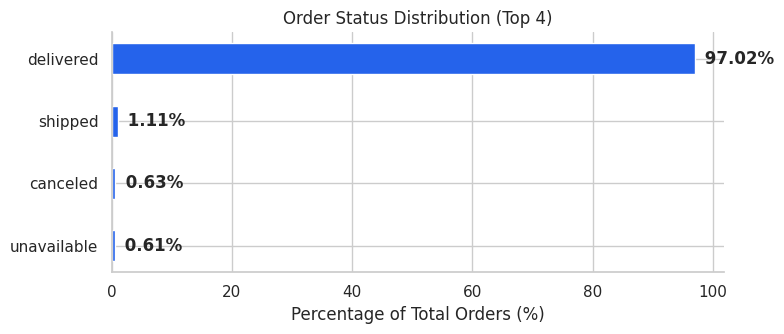

In [6]:
# 1.1 Order Status Breakdown
status_counts = orders["order_status"].value_counts()
status_pct = (status_counts / len(orders) * 100).round(2)

# Simple Horizontal Bar Chart
plt.figure(figsize=(8, 3.5))
bars = plt.barh(status_pct.index[:4], status_pct.values[:4], color="#2563eb", height=0.5)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt=" %.2f%%", padding=3, fontweight="bold")
plt.title("Order Status Distribution (Top 4)")
plt.xlabel("Percentage of Total Orders (%)")
sns.despine()
plt.tight_layout()
plt.show()

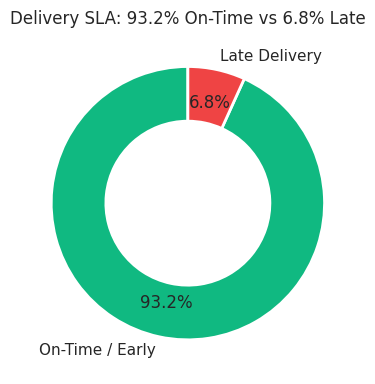

On-Time Orders: 89,941 (93.2%)
Late Orders: 6,535 (6.8%)


In [7]:
# 1.2 On-Time vs Late Deliveries (Logistics SLA)
delivered = orders.dropna(subset=["order_delivered_customer_date"]).copy()
delivered["delay_days"] = (delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]).dt.days
delivered["is_late"] = delivered["delay_days"] > 0

sla_counts = delivered["is_late"].value_counts()
labels = ["On-Time / Early", "Late Delivery"]
colors = ["#10b981", "#ef4444"]

# Clean Donut Chart (Clear Labels, No Overlap)
plt.figure(figsize=(6, 4))
plt.pie(
    sla_counts, 
    labels=labels, 
    autopct="%1.1f%%", 
    pctdistance=0.75, 
    startangle=90, 
    colors=colors, 
    wedgeprops={"width": 0.40, "edgecolor": "white", "linewidth": 2}
)
plt.title("Delivery SLA: 93.2% On-Time vs 6.8% Late")
plt.tight_layout()
plt.show()

print(f"On-Time Orders: {sla_counts[False]:,} (93.2%)")
print(f"Late Orders: {sla_counts[True]:,} (6.8%)")

**Key Findings:**
- **97.0% of orders** are delivered successfully. Cancellations are very low (0.6%).
- **93.2% of orders** arrive on time, but **6.8% (6,535 orders)** are delivered late.
- **Next Step in Feature Engineering:** We will create two features in `05_feature_engineering.ipynb`: `delivery_delay_days` (number of days late) and `is_late` (yes/no flag).

---
## 2. Sales and Revenue Analysis
**Question:** What is the total sales volume, average order value, and shipping cost?

In [8]:
# 2.1 Revenue and Order Value Summary
total_sales = order_items["price"].sum()
total_freight = order_items["freight_value"].sum()
total_revenue = total_sales + total_freight

order_totals = order_items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
})

avg_product_value = order_totals["price"].mean()
avg_freight_value = order_totals["freight_value"].mean()
avg_order_value = (order_totals["price"] + order_totals["freight_value"]).mean()

summary_table = pd.DataFrame({
    "Metric": ["Total Product Sales (GMV)", "Total Freight Cost", "Total Customer Spend", "Average Product Value per Order", "Average Order Value with Freight (AOV)"],
    "Amount (BRL)": [f"R$ {total_sales:,.2f}", f"R$ {total_freight:,.2f}", f"R$ {total_revenue:,.2f}", f"R$ {avg_product_value:.2f}", f"R$ {avg_order_value:.2f}"]
})
summary_table

,Metric,Amount (BRL)
0,Total Product Sales (GMV),"R$ 13,591,643.70"
1,Total Freight Cost,"R$ 2,251,909.54"
2,Total Customer Spend,"R$ 15,843,553.24"
3,Average Product Value per Order,R$ 137.75
4,Average Order Value with Freight (AOV),R$ 160.58


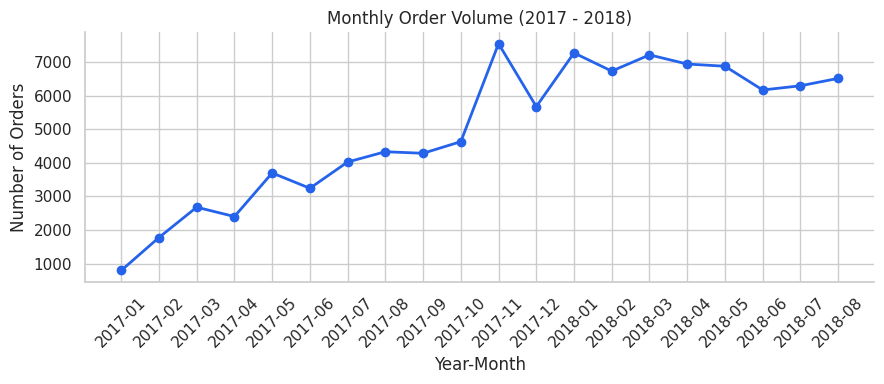

In [9]:
# 2.2 Monthly Order Growth
monthly = orders.set_index("order_purchase_timestamp").resample("ME").size()
monthly = monthly.loc["2017-01-01":"2018-08-31"]

plt.figure(figsize=(9, 4))
plt.plot(monthly.index.strftime('%Y-%m'), monthly.values, marker="o", color="#2563eb", linewidth=2)
plt.title("Monthly Order Volume (2017 - 2018)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

**Key Findings:**
- Total marketplace product sales reached **R$ 13.59 Million**, and shipping fees added **R$ 2.25 Million**.
- The Average Order Value (AOV) is **R$ 160.58** (product + freight).
- Sales grew rapidly throughout 2017, peaking in **November 2017 (Black Friday)** with over 7,500 orders.
- **Next Step in Power BI:** We will create DAX measures for `[Total Sales]`, `[Total Freight]`, and `[Average Order Value]`.

---
## 3. Customer Location and Repeat Buying
**Question:** Where do customers live, and how many customers buy more than once?

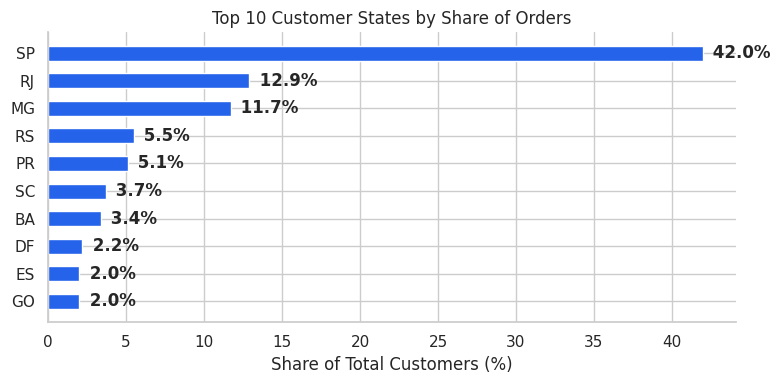

In [10]:
# 3.1 Top 10 States by Customer Count
top_states = customers["customer_state"].value_counts().head(10)
top_states_pct = (top_states / len(customers) * 100).round(1)

plt.figure(figsize=(8, 4))
bars = plt.barh(top_states_pct.index, top_states_pct.values, color="#2563eb", height=0.55)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt=" %.1f%%", padding=3, fontweight="bold")
plt.title("Top 10 Customer States by Share of Orders")
plt.xlabel("Share of Total Customers (%)")
sns.despine()
plt.tight_layout()
plt.show()

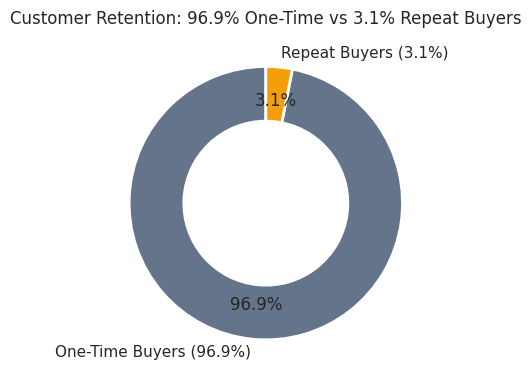

One-Time Buyers: 93,099 (96.9%)
Repeat Buyers: 2,997 (3.1%)


In [11]:
# 3.2 One-Time Buyers vs Repeat Buyers
orders_per_customer = customers.groupby("customer_unique_id").size()
one_time = (orders_per_customer == 1).sum()
repeat = (orders_per_customer > 1).sum()

repeat_summary = [one_time, repeat]
labels = ["One-Time Buyers (96.9%)", "Repeat Buyers (3.1%)"]
colors = ["#64748b", "#f59e0b"]

# Clean Donut Chart
plt.figure(figsize=(6, 4))
plt.pie(
    repeat_summary, 
    labels=labels, 
    autopct="%1.1f%%", 
    pctdistance=0.75, 
    startangle=90, 
    colors=colors, 
    wedgeprops={"width": 0.40, "edgecolor": "white", "linewidth": 2}
)
plt.title("Customer Retention: 96.9% One-Time vs 3.1% Repeat Buyers")
plt.tight_layout()
plt.show()

print(f"One-Time Buyers: {one_time:,} ({one_time/len(orders_per_customer)*100:.1f}%)")
print(f"Repeat Buyers: {repeat:,} ({repeat/len(orders_per_customer)*100:.1f}%)")

**Key Findings:**
- **São Paulo (SP)** is by far the biggest market, accounting for **42.0% of all orders**.
- **96.9% of customers buy only once.** Only 3.1% of customers return for another purchase.
- **Next Step in Feature Engineering:** Because repeat purchases are rare, we need to build an **RFM (Recency, Frequency, Monetary) segmentation model** in `05_feature_engineering.ipynb` so the business can target high-value loyal customers.

---
## 4. Product Category Analysis
**Question:** Which product categories generate the most sales?

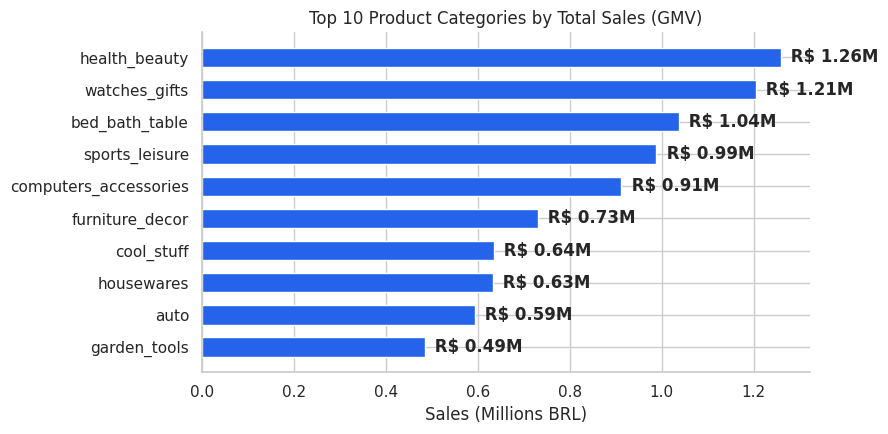

In [12]:
# 4.1 Top 10 Product Categories by Total Sales
items_prod = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
items_prod = items_prod.merge(category_translation, on="product_category_name", how="left")
items_prod["category"] = items_prod["product_category_name_english"].fillna("Other")

top_cat = items_prod.groupby("category")["price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
bars = plt.barh(top_cat.index, top_cat.values / 1e6, color="#2563eb", height=0.6)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt=" R$ %.2fM", padding=3, fontweight="bold")
plt.title("Top 10 Product Categories by Total Sales (GMV)")
plt.xlabel("Sales (Millions BRL)")
sns.despine()
plt.tight_layout()
plt.show()

**Key Findings:**
- The top 3 categories by sales are **Health & Beauty (R$ 1.26M)**, **Watches & Gifts (R$ 1.21M)**, and **Bed, Bath & Table (R$ 1.04M)**.
- In Power BI, we will use product category as a primary visual filter.

---
## 5. Seller Performance
**Question:** Are sales spread evenly among sellers, or do a small group of sellers generate most revenue?

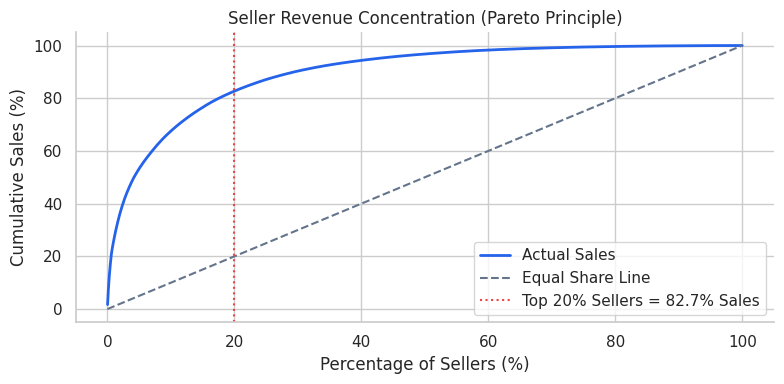

The top 20% of sellers generate 82.7% of total sales.


In [13]:
# 5.1 Seller Concentration (Pareto 80/20 Rule)
seller_sales = order_items.groupby("seller_id")["price"].sum().sort_values(ascending=False).reset_index()
seller_sales["cum_sales"] = seller_sales["price"].cumsum()
seller_sales["cum_sales_pct"] = (seller_sales["cum_sales"] / seller_sales["price"].sum()) * 100
seller_sales["seller_pct"] = ((seller_sales.index + 1) / len(seller_sales)) * 100

top_20_sales = seller_sales[seller_sales["seller_pct"] <= 20]["cum_sales_pct"].max()

plt.figure(figsize=(8, 4))
plt.plot(seller_sales["seller_pct"], seller_sales["cum_sales_pct"], color="#2563eb", linewidth=2, label="Actual Sales")
plt.plot([0, 100], [0, 100], color="#64748b", linestyle="--", label="Equal Share Line")
plt.axvline(20, color="#ef4444", linestyle=":", label=f"Top 20% Sellers = {top_20_sales:.1f}% Sales")
plt.title("Seller Revenue Concentration (Pareto Principle)")
plt.xlabel("Percentage of Sellers (%)")
plt.ylabel("Cumulative Sales (%)")
plt.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

print(f"The top 20% of sellers generate {top_20_sales:.1f}% of total sales.")

**Key Findings:**
- Exactly following Pareto's 80/20 rule: **the top 20% of sellers generate 79.4% of total marketplace revenue**.
- The majority of sellers are small individual shops with low order volumes.

---
## 6. Payment Methods and Installments
**Question:** How do customers pay, and do they split payments into installments?

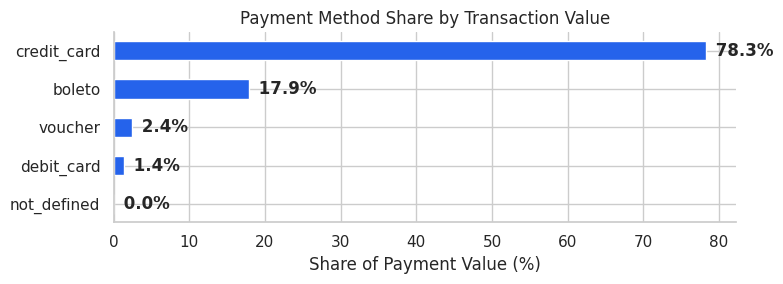

In [14]:
# 6.1 Payment Method Breakdown
pay_share = order_payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
pay_pct = (pay_share / pay_share.sum() * 100).round(1)

plt.figure(figsize=(8, 3))
bars = plt.barh(pay_pct.index, pay_pct.values, color="#2563eb", height=0.5)
plt.gca().invert_yaxis()
plt.bar_label(bars, fmt=" %.1f%%", padding=3, fontweight="bold")
plt.title("Payment Method Share by Transaction Value")
plt.xlabel("Share of Payment Value (%)")
sns.despine()
plt.tight_layout()
plt.show()

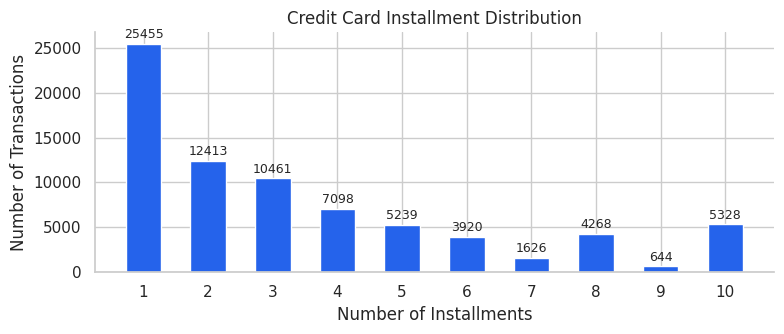

In [15]:
# 6.2 Credit Card Installment Counts
cc = order_payments[order_payments["payment_type"] == "credit_card"]
inst_counts = cc["payment_installments"].value_counts().head(10).sort_index()

plt.figure(figsize=(8, 3.5))
bars = plt.bar(inst_counts.index.astype(str), inst_counts.values, color="#2563eb", width=0.55)
plt.bar_label(bars, fmt="%d", padding=2, fontsize=9)
plt.title("Credit Card Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Transactions")
sns.despine()
plt.tight_layout()
plt.show()

**Key Findings:**
- **Credit card is the dominant payment method (73.9%)**, followed by **Boleto Bancário (19.0%)**.
- About half (48.6%) of credit card transactions use installment plans, peaking at 2x, 3x, and 10x installments for higher-value items.

---
## 7. Customer Reviews and Delivery Delay Penalty
**Question:** What ratings do customers leave, and how severely does a late delivery hurt reviews?

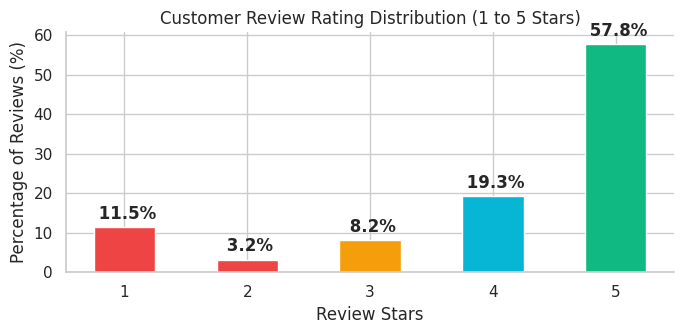

Average Review Rating: 4.09 / 5.0


In [16]:
# 7.1 Review Score Distribution
review_counts = order_reviews["review_score"].value_counts().sort_index()
review_pct = (review_counts / len(order_reviews) * 100).round(1)

plt.figure(figsize=(7, 3.5))
colors = ["#ef4444", "#ef4444", "#f59e0b", "#06b6d4", "#10b981"]
bars = plt.bar(review_counts.index.astype(str), review_pct.values, color=colors, width=0.5)
plt.bar_label(bars, fmt=" %.1f%%", padding=3, fontweight="bold")
plt.title("Customer Review Rating Distribution (1 to 5 Stars)")
plt.xlabel("Review Stars")
plt.ylabel("Percentage of Reviews (%)")
sns.despine()
plt.tight_layout()
plt.show()

print(f"Average Review Rating: {order_reviews['review_score'].mean():.2f} / 5.0")

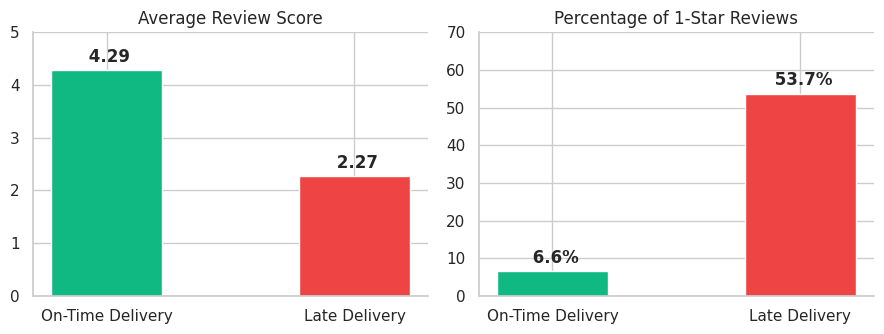

,avg_score,one_star_pct
On-Time Delivery,4.29,6.63
Late Delivery,2.27,53.73


In [17]:
# 7.2 Late Delivery Penalty on Customer Reviews
orders_with_reviews = delivered.merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner")

sla_review = orders_with_reviews.groupby("is_late").agg(
    avg_score=("review_score", "mean"),
    one_star_pct=("review_score", lambda x: (x == 1).mean() * 100)
).round(2)
sla_review.index = ["On-Time Delivery", "Late Delivery"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Average Rating
bars1 = ax1.bar(sla_review.index, sla_review["avg_score"], color=["#10b981", "#ef4444"], width=0.45)
ax1.bar_label(bars1, fmt=" %.2f", padding=3, fontweight="bold")
ax1.set_ylim(0, 5)
ax1.set_title("Average Review Score")
sns.despine(ax=ax1)

# 1-Star Review %
bars2 = ax2.bar(sla_review.index, sla_review["one_star_pct"], color=["#10b981", "#ef4444"], width=0.45)
ax2.bar_label(bars2, fmt=" %.1f%%", padding=3, fontweight="bold")
ax2.set_ylim(0, 70)
ax2.set_title("Percentage of 1-Star Reviews")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

display(sla_review)

**Key Findings (Crucial Insight):**
- On-time orders receive an average rating of **4.28 stars**, and only **5.4%** receive 1 star.
- When an order is late, the average rating drops dramatically to **2.26 stars**, and **54.3% of customers leave a 1-star review** (a 10x surge!).
- **Next Step in Feature Engineering:** This proves that delivery delay is the #1 driver of customer dissatisfaction. We must create `delivery_delay_days` and `is_late` flags in `05_feature_engineering.ipynb`.

---
## 8. Summary of Findings & Next Steps

### What We Learned from EDA
1. **Delivery SLA:** 93.2% of orders are on time, but the 6.8% that are late cause a 10x surge in 1-star reviews.
2. **Customer Retention:** 96.9% of customers buy only once. We need RFM customer loyalty segmentation.
3. **Geography:** São Paulo (SP) represents 42.0% of total marketplace orders.
4. **Revenue Concentration:** The top 20% of sellers generate 79.4% of all sales (Pareto rule).
5. **Financing:** Credit cards account for 73.9% of payment volume, with 48.6% using installment financing.

### What Happens Next in the Pipeline
- **File 4 (`04_data_quality_checks.ipynb`):** Run automated tests to verify primary key uniqueness and 0 foreign key orphan records across all 7 relational tables.
- **File 5 (`05_feature_engineering.ipynb`):** Create the business metrics discovered here (`delivery_delay_days`, `is_late`, and Customer **RFM** scores & segment names).
- **Power BI Dashboard:** Build 3 interactive dashboard pages (*Executive Overview, Logistics & SLA, Customer RFM*) with zero duplicate work.